# Tokenisasi — Deteksi Sarkasme pada Dataset SARC

Model transformer tidak bisa membaca teks secara langsung. Teks harus diubah dulu menjadi **deretan angka** (token ID). Proses ini disebut **tokenisasi**, dan itulah yang dikerjakan notebook ini.

**Alur kerja:**

```
data/split/*.parquet (teks bersih)
   → Gabungkan parent + comment menjadi satu input
   → Ubah menjadi token dengan tokenizer bawaan tiap model
   → Potong jika lebih dari 256 token (yang dipotong parent, bukan comment)
   → Simpan ke data/tokenized/
```

**Input:** `data/split/train.parquet`, `val.parquet`, `test.parquet`, `train_pilot.parquet`
**Output:** `data/tokenized/roberta/*.parquet`, `data/tokenized/distilbert/*.parquet`, `token_stats.csv`, dan `tokenization_config.json`

## 1. Setup & Konfigurasi

| Konfigurasi | Nilai | Keterangan |
|---|---|---|
| `MAX_LEN` | 256 | Panjang maksimum input dalam satuan token (proposal) |
| `TRUNCATION` | `only_first` | Jika terlalu panjang, yang dipotong adalah kalimat pertama (parent) |
| `MODELS` | `roberta-base`, `distilbert-base-uncased` | Setiap model memakai tokenizer bawaannya sendiri (proposal) |
| `SPLITS` | train, val, test, train_pilot | Semua bagian data ditokenisasi dengan cara yang sama |

DistilBERT memakai versi **uncased** karena teks sudah diubah menjadi huruf kecil pada tahap preprocessing.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import transformers
from transformers import AutoTokenizer

MAX_LEN = 256
TRUNCATION = "only_first"                 # yang dipotong parent (kalimat pertama)
MODELS = {
    "roberta": "roberta-base",
    "distilbert": "distilbert-base-uncased",
}
SPLITS = ["train", "val", "test", "train_pilot"]

ROOT = Path.cwd().parents[1]
SPLIT_DIR = ROOT / "data/split"
TOKENIZED_DIR = ROOT / "data/tokenized"
TOKENIZED_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")


[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


> **Catatan:** peringatan *"PyTorch was not found"* aman diabaikan di notebook ini. Tokenisasi tidak membutuhkan PyTorch. PyTorch baru diperlukan pada tahap training.

## 2. Load Data Split

Data dibaca dari hasil preprocessing, lalu jumlah barisnya dicocokkan dengan `split_config.json`. Tujuannya memastikan data yang ditokenisasi benar-benar data yang dihasilkan notebook `02_preprocessing`.

In [2]:
split_config = json.loads((SPLIT_DIR / "split_config.json").read_text())
FIRST_COL = split_config["text_columns"]["first"]      # parent_clean
SECOND_COL = split_config["text_columns"]["second"]    # comment_clean

data = {name: pd.read_parquet(SPLIT_DIR / f"{name}.parquet") for name in SPLITS}

summary = pd.DataFrame({
    name: {"Jumlah": len(d), "Sesuai config": len(d) == split_config["n_rows"][name],
           "% Sarkas": round(d["label"].mean() * 100, 2)}
    for name, d in data.items()
}).T
display(summary)
assert summary["Sesuai config"].all(), "Jumlah baris tidak sesuai split_config.json!"
print("Kalimat pertama:", FIRST_COL, "| Kalimat kedua:", SECOND_COL)


,Jumlah,Sesuai config,% Sarkas
train,160000,True,50.0
val,20000,True,50.0
test,20000,True,50.0
train_pilot,40000,True,50.0


Kalimat pertama: parent_clean | Kalimat kedua: comment_clean


#### Insight
- Jumlah data sesuai dengan konfigurasi: train 160.000, validasi 20.000, test 20.000, dan pilot 40.000. Semuanya 50% sarkas.
- Urutan input sudah ditetapkan: **parent sebagai kalimat pertama** dan **comment sebagai kalimat kedua**.

## 3. Load Tokenizer

Setiap model punya "kamus" (vocabulary) dan cara memecah kata sendiri, sehingga tokenizer RoBERTa tidak bisa dipakai untuk DistilBERT, dan sebaliknya.

In [3]:
tokenizers = {key: AutoTokenizer.from_pretrained(name) for key, name in MODELS.items()}

tok_info = pd.DataFrame({
    key: {
        "Checkpoint": MODELS[key],
        "Kelas tokenizer": type(tok).__name__,
        "Ukuran vocab": tok.vocab_size,
        "Special token (pasangan)": tok.num_special_tokens_to_add(pair=True),
        "Input model": ", ".join(tok.model_input_names),
    }
    for key, tok in tokenizers.items()
}).T
display(tok_info)


,Checkpoint,Kelas tokenizer,Ukuran vocab,Special token (pasangan),Input model
roberta,roberta-base,RobertaTokenizer,50265,4,"input_ids, attention_mask"
distilbert,distilbert-base-uncased,BertTokenizer,30522,3,"input_ids, token_type_ids, attention_mask"


#### Insight

| | RoBERTa | DistilBERT |
|---|---|---|
| Ukuran kamus | 50.265 token | 30.522 token |
| Cara memecah kata | Byte-Pair Encoding (BPE) | WordPiece |
| Token khusus untuk sepasang kalimat | 4 | 3 |

- **Token khusus** adalah penanda yang ditambahkan otomatis, misalnya tanda awal input dan pemisah antarkalimat. Token ini ikut dihitung dalam batas 256.
- Tokenizer DistilBERT juga mengeluarkan `token_type_ids`, tetapi kolom ini tidak dipakai, karena RoBERTa dan DistilBERT sama-sama tidak menggunakannya. Yang disimpan hanya `input_ids` dan `attention_mask`.
- Peringatan *"unauthenticated requests to the HF Hub"* aman diabaikan.

## 4. Contoh Format Input Pasangan

Satu pasangan ditokenisasi sebagai contoh, untuk melihat seperti apa input yang diterima model.

In [4]:
example = data["train"].iloc[0]
for key, tok in tokenizers.items():
    enc = tok(example[FIRST_COL], example[SECOND_COL])
    print(f"=== {MODELS[key]} ===")
    print("Teks hasil decode:", tok.decode(enc["input_ids"]))
    print("Token:", tok.convert_ids_to_tokens(enc["input_ids"]))
    print()


=== roberta-base ===
Teks hasil decode: <s>it s a convenience store or gas station on the east coast they are family owned and not a franchise they are usually very clean and have good quality food</s></s>weird i live in nc and have never seen one</s>
Token: ['<s>', 'it', 'Ġs', 'Ġa', 'Ġconvenience', 'Ġstore', 'Ġor', 'Ġgas', 'Ġstation', 'Ġon', 'Ġthe', 'Ġeast', 'Ġcoast', 'Ġthey', 'Ġare', 'Ġfamily', 'Ġowned', 'Ġand', 'Ġnot', 'Ġa', 'Ġfranchise', 'Ġthey', 'Ġare', 'Ġusually', 'Ġvery', 'Ġclean', 'Ġand', 'Ġhave', 'Ġgood', 'Ġquality', 'Ġfood', '</s>', '</s>', 'we', 'ird', 'Ġi', 'Ġlive', 'Ġin', 'Ġn', 'c', 'Ġand', 'Ġhave', 'Ġnever', 'Ġseen', 'Ġone', '</s>']

=== distilbert-base-uncased ===
Teks hasil decode: [CLS] it s a convenience store or gas station on the east coast they are family owned and not a franchise they are usually very clean and have good quality food [SEP] weird i live in nc and have never seen one [SEP]
Token: ['[CLS]', 'it', 's', 'a', 'convenience', 'store', 'or', 'gas', 'statio

#### Insight
- Parent dan comment digabung menjadi **satu input** dengan pemisah di tengahnya:
  - RoBERTa: `<s> parent </s></s> comment </s>`
  - DistilBERT: `[CLS] parent [SEP] comment [SEP]`
- Dengan format ini, model bisa "melihat" parent dan comment sekaligus dan mempelajari hubungan keduanya. Ini sesuai temuan EDA bahwa sarkasme muncul dari interaksi comment dengan konteksnya.
- Kata yang jarang dipecah menjadi potongan lebih kecil (*subword*). Contohnya pada RoBERTa, `weird` menjadi `we` + `ird` dan `nc` menjadi `n` + `c`. Karena itu jumlah token biasanya lebih banyak daripada jumlah kata.
- Simbol `Ġ` pada token RoBERTa hanya menandakan ada spasi sebelum kata tersebut.

## 5. Fungsi Tokenisasi

Fungsi `tokenize_pairs` mengubah semua pasangan dalam satu split menjadi token. Aturannya:

1. **Jika total token ≤ 256**, input dipakai apa adanya.
2. **Jika total token > 256**, yang dipotong adalah **parent** (`only_first`). Comment dijaga tetap utuh, karena comment adalah teks yang dinilai sarkas atau tidak.
3. **Kasus khusus**: jika comment-nya sendiri sudah melebihi batas, parent tidak bisa dipotong lagi dan `only_first` akan error. Untuk kasus ini dipakai `longest_first`, yaitu memotong bagian yang paling panjang.

Fungsi ini juga mencatat panjang asli sebelum dipotong (`n_tokens_full`), apakah input terpotong (`truncated`), dan apakah memakai aturan khusus (`fallback`).

In [5]:
def tokenize_pairs(tok, df):
    parents = df[FIRST_COL].tolist()
    comments = df[SECOND_COL].tolist()

    # Batas panjang comment agar parent masih bisa dipotong (minimal tersisa 1 token)
    budget = MAX_LEN - tok.num_special_tokens_to_add(pair=True)
    comment_len = np.array([len(ids) for ids in tok(comments, add_special_tokens=False)["input_ids"]])
    full_len = np.array([len(ids) for ids in tok(parents, comments)["input_ids"]])
    fallback = comment_len >= budget

    input_ids = [None] * len(df)
    attention_mask = [None] * len(df)
    for mask, strategy in [(~fallback, TRUNCATION), (fallback, "longest_first")]:
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue
        enc = tok([parents[i] for i in idx], [comments[i] for i in idx],
                  truncation=strategy, max_length=MAX_LEN)
        for j, i in enumerate(idx):
            input_ids[i] = enc["input_ids"][j]
            attention_mask[i] = enc["attention_mask"][j]

    out = pd.DataFrame({
        "raw_idx": df["raw_idx"].to_numpy(),
        "label": df["label"].to_numpy(),
        "input_ids": input_ids,
        "attention_mask": attention_mask,
    })
    out["n_tokens"] = out["input_ids"].str.len()
    out["n_tokens_full"] = full_len               # panjang sebelum dipotong
    out["truncated"] = full_len > MAX_LEN
    out["fallback"] = fallback
    return out


## 6. Tokenisasi Semua Split

Fungsi di atas dijalankan untuk 2 model × 4 split.

In [6]:
tokenized = {}
for key, tok in tokenizers.items():
    for split, df in data.items():
        tokenized[(key, split)] = tokenize_pairs(tok, df)
        print(f"{key:10s} {split:12s} selesai: {len(df):,} pasangan")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (4443 > 512). Running this sequence through the model will result in indexing errors


roberta    train        selesai: 160,000 pasangan
roberta    val          selesai: 20,000 pasangan
roberta    test         selesai: 20,000 pasangan
roberta    train_pilot  selesai: 40,000 pasangan


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2222 > 512). Running this sequence through the model will result in indexing errors


distilbert train        selesai: 160,000 pasangan
distilbert val          selesai: 20,000 pasangan
distilbert test         selesai: 20,000 pasangan
distilbert train_pilot  selesai: 40,000 pasangan


> **Catatan:** peringatan *"Token indices sequence length is longer than the specified maximum (4443 > 512)"* aman diabaikan. Peringatan ini muncul karena panjang asli sengaja diukur **tanpa pemotongan** terlebih dahulu. Input yang disimpan sudah dipotong menjadi maksimal 256 token.

## 7. Statistik Panjang Token

Ringkasan panjang input untuk setiap model dan split, sebelum dan sesudah pemotongan.

In [7]:
rows = []
for (key, split), t in tokenized.items():
    rows.append({
        "Model": key, "Split": split, "Jumlah": len(t),
        "Median token (asli)": t["n_tokens_full"].median(),
        "P95 token (asli)": t["n_tokens_full"].quantile(0.95),
        "P99 token (asli)": t["n_tokens_full"].quantile(0.99),
        "Maks token (setelah)": t["n_tokens"].max(),
        "Terpotong": int(t["truncated"].sum()),
        "% terpotong": t["truncated"].mean() * 100,
        "Fallback longest_first": int(t["fallback"].sum()),
    })
token_stats = pd.DataFrame(rows).set_index(["Model", "Split"]).round(2)
display(token_stats)
assert token_stats["Maks token (setelah)"].max() <= MAX_LEN


Jumlah  Median token (asli)  P95 token (asli)  \
Model      Split                                                        
roberta    train        160000                 32.0             106.0   
           val           20000                 32.0             109.0   
           test          20000                 32.0             108.0   
           train_pilot   40000                 32.0             105.0   
distilbert train        160000                 31.0             105.0   
           val           20000                 31.0             107.0   
           test          20000                 31.0             106.0   
           train_pilot   40000                 30.0             104.0   

                        P99 token (asli)  Maks token (setelah)  Terpotong  \
Model      Split                                                            
roberta    train                  215.00                   256       1054   
           val                    222.00                   256        145   
           test                   216.00                   256        127   
           train_pilot            213.00                   256        279   
distilbert train                  214.00                   256       1044   
           val                    219.01                   256        141   
           test                   214.01                   256        127   
           train_pilot            213.00                   256        270   

                        % terpotong  Fallback longest_first  
Model      Split                                             
roberta    train               0.66                      12  
           val                 0.73                       3  
           test                0.64                       3  
           train_pilot         0.70                       3  
distilbert train               0.65                      10  
           val                 0.70                       2  
           test                0.64                       2  
           train_pilot         0.68                       3

#### Insight
- **Sebagian besar input pendek.** Median hanya sekitar **32 token** (RoBERTa) dan **31 token** (DistilBERT). Artinya separuh data lebih pendek dari itu.
- **99% input berada di bawah ±222 token**, sehingga batas 256 sudah cukup longgar.
- **Hanya 0,64%–0,73% input yang terpotong** (1.054 dari 160.000 pasangan train pada RoBERTa). Ini sejalan dengan perkiraan di EDA (±0,6%) dan menegaskan bahwa `max_length = 256` pada proposal sudah tepat.
- **Aturan khusus `longest_first` hanya terpakai pada 12 pasangan train** (0,008%) untuk RoBERTa dan 10 pasangan untuk DistilBERT. Jumlahnya sangat kecil sehingga tidak memengaruhi hasil.
- **Setelah diproses, tidak ada input yang lebih dari 256 token.**
- Angka RoBERTa dan DistilBERT hampir sama, jadi kedua model menerima input dengan panjang yang setara. Perbandingan efisiensi keduanya nanti menjadi adil.

## 8. Visualisasi Panjang Token

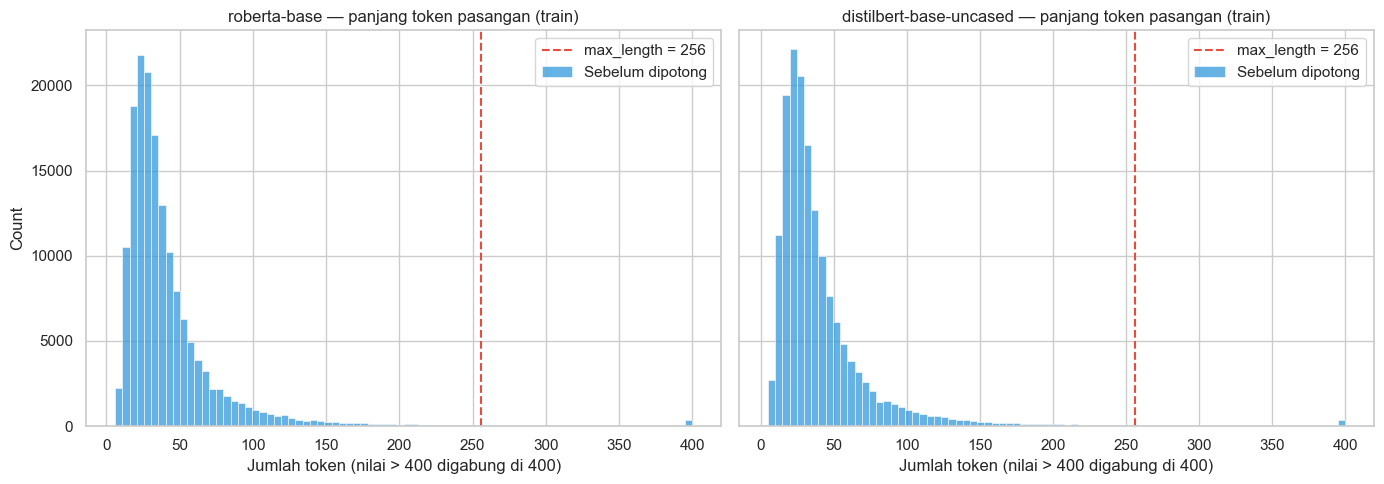

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, key in zip(axes, MODELS):
    t = tokenized[(key, "train")]
    sns.histplot(t["n_tokens_full"].clip(upper=400), bins=80, ax=ax, color="#3498DB", label="Sebelum dipotong")
    ax.axvline(MAX_LEN, color="#E74C3C", ls="--", label=f"max_length = {MAX_LEN}")
    ax.set_title(f"{MODELS[key]} — panjang token pasangan (train)")
    ax.set_xlabel("Jumlah token (nilai > 400 digabung di 400)")
    ax.legend()
plt.tight_layout()
plt.show()


#### Insight
- Distribusinya menumpuk di kiri: kebanyakan input sangat pendek, dan hanya sedikit yang panjang.
- Garis merah putus-putus adalah batas 256 token. Hampir seluruh data berada di sebelah kirinya, sehingga hanya sebagian kecil yang perlu dipotong.
- Karena kebanyakan input jauh lebih pendek dari 256, **padding tidak dilakukan di sini**. Padding dilakukan per batch saat training (*dynamic padding*), sehingga model tidak membuang waktu memproses ratusan token kosong.

## 9. Cek: Comment Tetap Utuh Saat Dipotong

Pemeriksaan ini memastikan bahwa pada input yang terpotong, **yang hilang hanya bagian parent**. Caranya: token comment dibandingkan dengan bagian akhir input. Jika sama persis, berarti comment tidak ikut terpotong.

In [9]:
check_rows = []
for key, tok in tokenizers.items():
    t = tokenized[(key, "train")]
    df = data["train"]
    cut = t.index[t["truncated"] & ~t["fallback"]]
    ok = 0
    for i in cut:
        comment_ids = tok(df[SECOND_COL].iloc[i], add_special_tokens=False)["input_ids"]
        ok += t["input_ids"].iloc[i][-(len(comment_ids) + 1):-1] == comment_ids
    check_rows.append({"Model": key, "Pasangan terpotong (only_first)": len(cut),
                       "Comment tetap utuh": ok})
trunc_check = pd.DataFrame(check_rows).set_index("Model")
display(trunc_check)
assert (trunc_check.iloc[:, 0] == trunc_check.iloc[:, 1]).all(), "Ada comment yang ikut terpotong!"

# Contoh satu pasangan yang terpotong
key, tok = "roberta", tokenizers["roberta"]
t = tokenized[(key, "train")]
i = t.index[t["truncated"] & ~t["fallback"]][0]
print("Panjang asli:", t.loc[i, "n_tokens_full"], "-> setelah dipotong:", t.loc[i, "n_tokens"])
print("Comment asli :", data["train"][SECOND_COL].iloc[i])
print("Akhir input  :", tok.decode(t.loc[i, "input_ids"][-40:]))


,Pasangan terpotong (only_first),Comment tetap utuh
Model,,
roberta,1042,1042
distilbert,1034,1034


Panjang asli: 282 -> setelah dipotong: 256
Comment asli : enjoy your ruined country
Akhir input  :  can possibly be i apologise for any typos i am from eastern europe and am typing this on a phone i just stole from an unsuspecting citizen of a more</s></s>enjoy your ruined country</s>


#### Insight
- **Semua comment tetap utuh**: 1.042 dari 1.042 pasangan (RoBERTa) dan 1.034 dari 1.034 pasangan (DistilBERT).
- Contoh: sebuah pasangan dengan panjang asli **282 token** dipotong menjadi **256 token**. Comment *"enjoy your ruined country"* tetap lengkap di akhir input, dan yang dibuang hanya bagian awal parent.
- Dengan begitu model selalu melihat komentar yang dinilai secara penuh, ditambah konteks parent sebanyak yang muat.

## 10. Simpan Hasil Tokenisasi

Hasil disimpan terpisah per model, karena token ID RoBERTa dan DistilBERT berbeda. Kolom yang disimpan:

| Kolom | Fungsi |
|---|---|
| `input_ids` | **Input model**: deretan token ID |
| `attention_mask` | **Input model**: penanda token mana yang harus diperhatikan model (semua bernilai 1 karena belum ada padding) |
| `label` | **Target**: 1 = sarkas, 0 = non-sarkas |
| `raw_idx` | Nomor baris asli, untuk mencocokkan hasil prediksi dengan teks aslinya |
| `n_tokens` | Panjang input setelah dipotong |

Konfigurasi tokenisasi disimpan ke `tokenization_config.json` agar proses ini bisa diulang dengan hasil yang sama.

In [10]:
SAVE_COLS = ["raw_idx", "label", "input_ids", "attention_mask", "n_tokens"]

for (key, split), t in tokenized.items():
    out_dir = TOKENIZED_DIR / key
    out_dir.mkdir(parents=True, exist_ok=True)
    t[SAVE_COLS].to_parquet(out_dir / f"{split}.parquet", index=False)

token_stats.to_csv(TOKENIZED_DIR / "token_stats.csv")

tok_config = {
    "max_length": MAX_LEN,
    "truncation": TRUNCATION,
    "truncation_fallback": "longest_first (hanya jika comment sendiri > batas)",
    "padding": "dinamis per batch saat training (DataCollatorWithPadding)",
    "input_format": {"first": FIRST_COL, "second": SECOND_COL},
    "models": MODELS,
    "transformers_version": transformers.__version__,
    "n_rows": {f"{k}/{s}": len(t) for (k, s), t in tokenized.items()},
    "n_truncated": {f"{k}/{s}": int(t["truncated"].sum()) for (k, s), t in tokenized.items()},
    "n_fallback": {f"{k}/{s}": int(t["fallback"].sum()) for (k, s), t in tokenized.items()},
}
(TOKENIZED_DIR / "tokenization_config.json").write_text(json.dumps(tok_config, indent=2))
print(json.dumps(tok_config, indent=2))


{
  "max_length": 256,
  "truncation": "only_first",
  "truncation_fallback": "longest_first (hanya jika comment sendiri > batas)",
  "padding": "dinamis per batch saat training (DataCollatorWithPadding)",
  "input_format": {
    "first": "parent_clean",
    "second": "comment_clean"
  },
  "models": {
    "roberta": "roberta-base",
    "distilbert": "distilbert-base-uncased"
  },
  "transformers_version": "5.17.0",
  "n_rows": {
    "roberta/train": 160000,
    "roberta/val": 20000,
    "roberta/test": 20000,
    "roberta/train_pilot": 40000,
    "distilbert/train": 160000,
    "distilbert/val": 20000,
    "distilbert/test": 20000,
    "distilbert/train_pilot": 40000
  },
  "n_truncated": {
    "roberta/train": 1054,
    "roberta/val": 145,
    "roberta/test": 127,
    "roberta/train_pilot": 279,
    "distilbert/train": 1044,
    "distilbert/val": 141,
    "distilbert/test": 127,
    "distilbert/train_pilot": 270
  },
  "n_fallback": {
    "roberta/train": 12,
    "roberta/val": 3,
  

## 11. Verifikasi File Tersimpan

File yang sudah disimpan dibaca kembali, lalu token ID baris pertama diubah lagi menjadi teks (*decode*) untuk memastikan isinya benar.

In [11]:
for key in MODELS:
    t = pd.read_parquet(TOKENIZED_DIR / key / "train.parquet")
    tok = tokenizers[key]
    print(f"=== {key}: {t.shape} ===")
    display(t.head(3))
    print("Decode baris pertama:", tok.decode(t["input_ids"].iloc[0]))
    print()


=== roberta: (160000, 5) ===


,raw_idx,label,input_ids,attention_mask,n_tokens
0,784665,0,"[0, 405, 579, 10, 9742, 1400, 50, 1123, 1992, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",46
1,364792,0,"[0, 118, 218, 326, 120, 99, 5, 477, 9, 15160, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",84
2,389036,1,"[0, 12229, 14, 579, 2555, 7, 920, 1672, 881, 6...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",28


Decode baris pertama: <s>it s a convenience store or gas station on the east coast they are family owned and not a franchise they are usually very clean and have good quality food</s></s>weird i live in nc and have never seen one</s>

=== distilbert: (160000, 5) ===


,raw_idx,label,input_ids,attention_mask,n_tokens
0,784665,0,"[101, 2009, 1055, 1037, 15106, 3573, 2030, 380...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",43
1,364792,0,"[101, 1045, 2123, 1056, 2131, 2054, 1996, 2391...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",83
2,389036,1,"[101, 4931, 2008, 1055, 5805, 2000, 26983, 230...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",26


Decode baris pertama: [CLS] it s a convenience store or gas station on the east coast they are family owned and not a franchise they are usually very clean and have good quality food [SEP] weird i live in nc and have never seen one [SEP]



#### Insight
- Kedua file train berisi **160.000 baris dan 5 kolom**.
- Hasil *decode* baris pertama sama dengan contoh di bagian 4, sehingga data tersimpan dengan benar.
- Pasangan yang sama menghasilkan jumlah token yang sedikit berbeda (46 token pada RoBERTa, 43 pada DistilBERT), karena kedua tokenizer memecah kata dengan cara berbeda.

## 12. Kesimpulan & Langkah Selanjutnya

### Kesimpulan
1. **Format input sesuai proposal.** Parent dan comment digabung dalam satu input, dengan tokenizer bawaan masing-masing model.
2. **`max_length = 256` terbukti cukup.** Hanya sekitar 0,7% input yang terpotong.
3. **Comment selalu utuh.** Pemotongan hanya mengenai parent, kecuali pada belasan pasangan yang comment-nya sendiri sangat panjang.
4. **Kedua model menerima data yang setara**: pasangan yang sama, urutan yang sama, dan panjang input yang hampir sama.
5. **Data siap untuk training** dan tersimpan di `data/tokenized/`.
